In [1]:
import sys
import torch
import polars as pl

from modeling_module.data_loader.MultiPartDataModule import MultiPartDataModule

'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR

In [2]:
target_dyn_demand_weekly = pl.read_parquet(DIR + 'target_dyn_demand_weekly.parquet').sort(['oper_part_no', 'demand_dt'])
target_dyn_demand_weekly

oper_part_no,demand_dt,demand_qty
str,i64,f64
"""0001-1001""",201811,5.0
"""0001-1001""",201847,7.0
"""0001-1001""",202005,20.0
"""0001-1001""",202006,100.0
"""0001-1001""",202010,2.0
…,…,…
"""ZZ90239""",202043,1.0
"""ZZ90239""",202145,1.0
"""ZZ90239""",202325,1.0


In [3]:
from modeling_module.models.PatchTST.supervised.backbone import SupervisedBackbone
from modeling_module.models.PatchTST.common.configs import PatchTSTConfigWeekly

cfg = PatchTSTConfigWeekly(
    c_in=1,
    target_dim=1,
    lookback=54,
    horizon=27,
    patch_len=4,
    stride=2,
)

model = SupervisedBackbone(cfg)
x = torch.randn(8, cfg.c_in, cfg.lookback)
out = model(x)

print(out.shape)  # [8, L_tok, d_model]

torch.Size([8, 26, 128])


In [4]:
plan_yyyymm = 201811
lookback = 54
horizon = 27

data_module = MultiPartDataModule(
    target_dyn_demand_weekly.sort(['oper_part_no', 'demand_dt']),
    lookback = lookback,
    horizon = horizon,
    batch_size = 64,
    val_ratio = 0.2,
    is_running = True
)

train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

In [5]:
from modeling_module.training.model_trainers.total_train import run_total_train_monthly

mode_dict = run_total_train_monthly(
    train_loader,
    val_loader,
    lookback = lookback,
    horizon = horizon,
)

PatchMixer Base


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1037.)
  return F.conv1d(


Epoch 1/1 | LR 0.000976 | Train 36.699484 | Val 36.382918
PatchMixer Quantile
Epoch 1/1 | LR 0.000976 | Train 16.222478 | Val 15.988396


In [13]:
from modeling_module.utils.checkpoint import save_model_dict, load_model_dict
from modeling_module.utils.exogenous_utils import calendar_cb
from modeling_module.models.PatchTST.common.configs import PatchTSTConfigMonthly
from modeling_module.models.Titan.common.configs import TitanConfigMonthly, TitanConfigPatchMonthly
from modeling_module.models.PatchMixer.common.configs import PatchMixerConfigMonthly

save_dir = DIR + 'fit/20251102_running'
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

pm_base_config = PatchMixerConfigMonthly(
        device = device,
        loss_mode = 'point',
        point_loss = 'mae'
    )

pm_quantile_config = PatchMixerConfigMonthly(
    device = device,
    loss_mode = 'quantile',
    quantiles = (0.1, 0.5, 0.9)
)

# ti_config = TitanConfigMonthly(
#         device = device,
#         loss_mode = 'point',
#         point_loss = 'mae'
#     )
#
# ti_patch_config = TitanConfigPatchMonthly(
#     device = device,
#     loss_mode = 'point',
#     point_loss = 'mae'
# )
#
# pt_config = PatchTSTConfigMonthly(
#         device = device,
#         loss_mode = 'auto',
#         quantiles = (0.1, 0.5, 0.9)
#     )

cfg_map = {
    "PatchMixer Base": pm_base_config,
    "PatchMixer Quantile": pm_quantile_config,
    # "Titan Base": ti_config,
    # "Titan LMM": ti_config,
    # "Titan Seq2Seq": ti_config,
    # "Titan Patch": ti_patch_config,
    # "PatchTST Base": pt_config,
    # "PatchTST Quantile": pt_config
}

builder_key_by_name = {
  "PatchMixer Base": "patchmixer_base",
  "PatchMixer Quantile": "patchmixer_quantile",
  # "Titan Base": "titan_base",
  # "Titan LMM": "titan_lmm",
  # "Titan Seq2Seq": "titan_seq2seq",
  # "Titan Patch": "titan_patch",
  # "PatchTST Base": "patchtst_base",
  # "PatchTST Quantile": "patchtst_quantile",
}
save_index = save_model_dict(mode_dict, save_dir, cfg_by_name = cfg_map, builder_key_by_name=builder_key_by_name)

# Load
from modeling_module.models.model_builder import (
    build_patch_mixer_base, build_patch_mixer_quantile,
    build_titan_base, build_titan_lmm, build_titan_seq2seq,
    build_patchTST_base, build_patchTST_quantile, build_titan_patch,
)

builders = {
    "patchmixer_base": lambda cfg: build_patch_mixer_base(cfg or PatchMixerConfigMonthly()),
    "patchmixer_quantile": lambda cfg: build_patch_mixer_quantile(cfg or PatchMixerConfigMonthly()),
    # "titan_base": lambda cfg: build_titan_base(cfg or TitanConfigMonthly()),
    # "titan_lmm": lambda cfg: build_titan_lmm(cfg or TitanConfigMonthly()),
    # "titan_seq2seq": lambda cfg: build_titan_seq2seq(cfg or TitanConfigMonthly()),
    # 'titan_patch': lambda cfg: build_titan_patch(cfg or TitanConfigPatchMonthly()),
    # "patchtst_base": lambda cfg: build_patchTST_base(cfg or PatchTSTConfigMonthly()),
    # "patchtst_quantile": lambda cfg: build_patchTST_quantile(cfg or PatchTSTConfigMonthly()),
}
loaded = load_model_dict(save_dir, builders, device = device)



[load] patchmixer_base ← /Users/igwanhyeong/PycharmProjects/data_research/raw_data/fit/20251102_running/patchmixer_base.pt
[load] patchmixer_quantile ← /Users/igwanhyeong/PycharmProjects/data_research/raw_data/fit/20251102_running/patchmixer_quantile.pt


In [14]:
model = loaded["patchmixer_base"].to(device).eval()
x1 = next(iter(val_loader))[0][:1].to(device)   # [1, L, C] or [1, L]

# (A) 직접 forward
with torch.no_grad():
    yA = model(x1)
    # dict/quantile 형태면 중앙값을 뽑도록 해석
    if isinstance(yA, dict):
        yA = yA.get("point", yA.get("q"))
        if yA.dim() == 3:  # [B,H,Q]
            yA = yA[..., 1]  # q50
    if yA.dim() == 3:       # [B,H,1] 등
        yA = yA.squeeze(-1)
    if yA.dim() == 1:
        yA = yA.view(1, -1)

# (B) 포캐스터 경유
from modeling_module.training.forecaster import DMSForecaster
f = DMSForecaster(model, target_channel=0, future_exo_cb=None)
with torch.no_grad():
    yB = f.forecast_DMS_to_IMS(x_init=x1, horizon=yA.size(1), device=device, extend="ims")

print("forward vs forecaster MSE:", float(((yA - yB)**2).mean()))
print("yA min/max/mean:", float(yA.min()), float(yA.max()), float(yA.mean()))
print("yB min/max/mean:", float(yB.min()), float(yB.max()), float(yB.mean()))

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.0356376, first5=[4.2062, 4.62405, 4.8373, 4.90507, 4.82634]
[FCAST-DBG] DMS step=0: raw_n=4.2062
[FCAST-DBG] DMS step=1: raw_n=4.62405
[FCAST-DBG] DMS step=2: raw_n=4.8373
[FCAST-DBG] DMS step=3: raw_n=4.90507
[FCAST-DBG] DMS step=4: raw_n=4.82634
[FCAST-DBG] DONE: H=27, var=0.0356376, first5=[4.2062, 4.62405, 4.8373, 4.90507, 4.82634]
forward vs forecaster MSE: 0.0
yA min/max/mean: 4.206201076507568 5.128833770751953 4.858480453491211
yB min/max/mean: 4.206201076507568 5.128833770751953 4.858480453491211


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.0534356, first5=[4.75588, 5.34457, 5.61304, 5.69607, 5.60134]
[FCAST-DBG] DMS step=0: raw_n=4.75588
final
[FCAST-DBG] DMS step=1: raw_n=5.34457
final
[FCAST-DBG] DMS step=2: raw_n=5.61304
final
[FCAST-DBG] DMS step=3: raw_n=5.69607
final
[FCAST-DBG] DMS step=4: raw_n=5.60134
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
[FCAST-DBG] DONE: H=27, var=1.6745e+07, first5=[95.0317, 119.159, 147.682, 180.102, 214.675]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.38766 q50=5.68472 q90=48.7867
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.50638 q50=11.7202 q90=146.24
[Q-IMS][PatchMixer QuantileModel] t=2 q10=1.37478 q50=9.97989 q90=121.674
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.25243 q50=8.48866 q90=99.2622
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.32322 q50=5.7558 q90=51.02

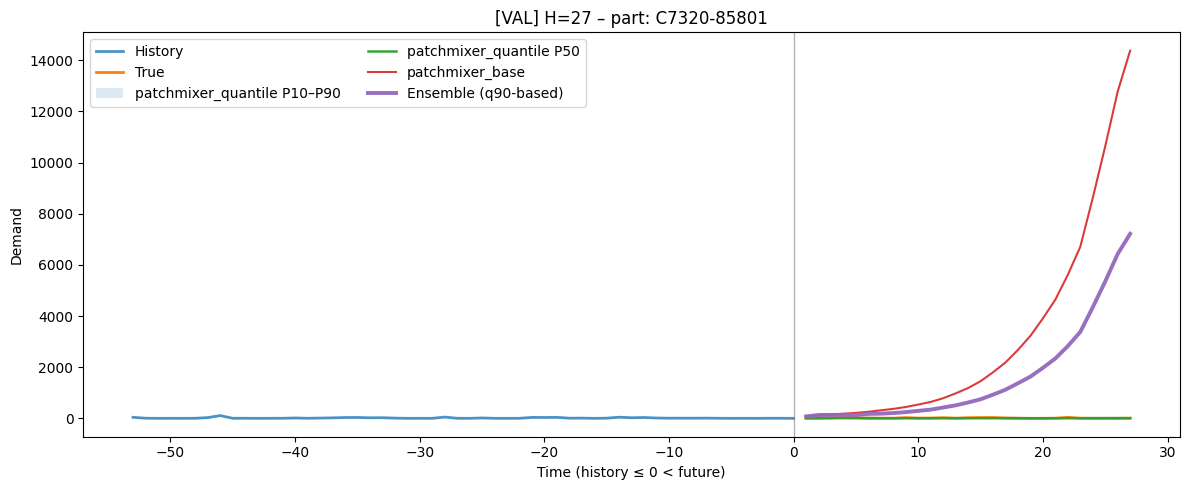

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.0332883, first5=[6.45378, 5.86309, 5.73063, 5.8132, 5.80615]
[FCAST-DBG] DMS step=0: raw_n=6.45378
final
[FCAST-DBG] DMS step=1: raw_n=5.86309
final
[FCAST-DBG] DMS step=2: raw_n=5.73063
final
[FCAST-DBG] DMS step=3: raw_n=5.8132
final
[FCAST-DBG] DMS step=4: raw_n=5.80615
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
[FCAST-DBG] DONE: H=27, var=2.32619e+07, first5=[71.0006, 81.8325, 97.7091, 119.205, 145.386]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.2979 q50=5.23694 q90=41.5329
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.10104 q50=4.39826 q90=30.0863
[Q-IMS][PatchMixer QuantileModel] t=2 q10=1.4318 q50=5.08722 q90=36.8481
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.11207 q50=4.4093 q90=30.0973
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.46031 q50=5.16132 q90=37.6982
[PLOT-DBG] patchmixer_base point(H=27): var(H)=2.24003e+07, mean(H)=3360.79, unique(H)=

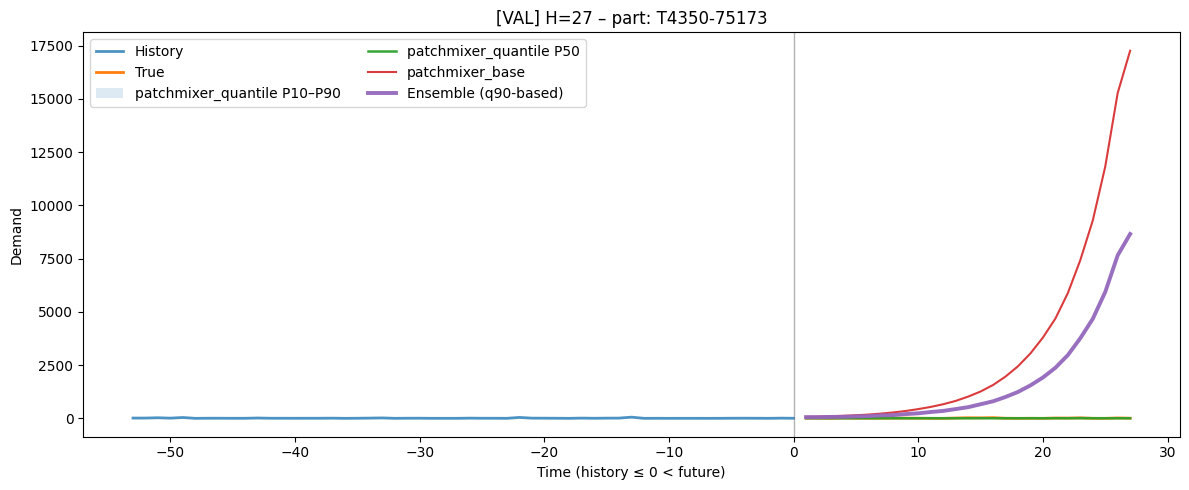

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.0390065, first5=[5.66629, 4.85068, 4.71174, 4.77106, 4.74634]
[FCAST-DBG] DMS step=0: raw_n=5.66629
final
[FCAST-DBG] DMS step=1: raw_n=4.85068
final
[FCAST-DBG] DMS step=2: raw_n=4.71174
final
[FCAST-DBG] DMS step=3: raw_n=4.77106
final
[FCAST-DBG] DMS step=4: raw_n=4.74634
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
[FCAST-DBG] DONE: H=27, var=27874.4, first5=[18.3869, 19.2131, 21.4597, 24.7027, 27.8445]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.02951 q50=4.43071 q90=31.5288
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.04464 q50=4.33515 q90=29.9368
[Q-IMS][PatchMixer QuantileModel] t=2 q10=1.0238 q50=4.46201 q90=32.096
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.04374 q50=4.34096 q90=30.029
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.04374 q50=4.34096 q90=30.029
[PLOT-DBG] patchmixer_base point(H=27): var(H)=26842, mean(H)=167.504, unique(H)=27
[PLOT-

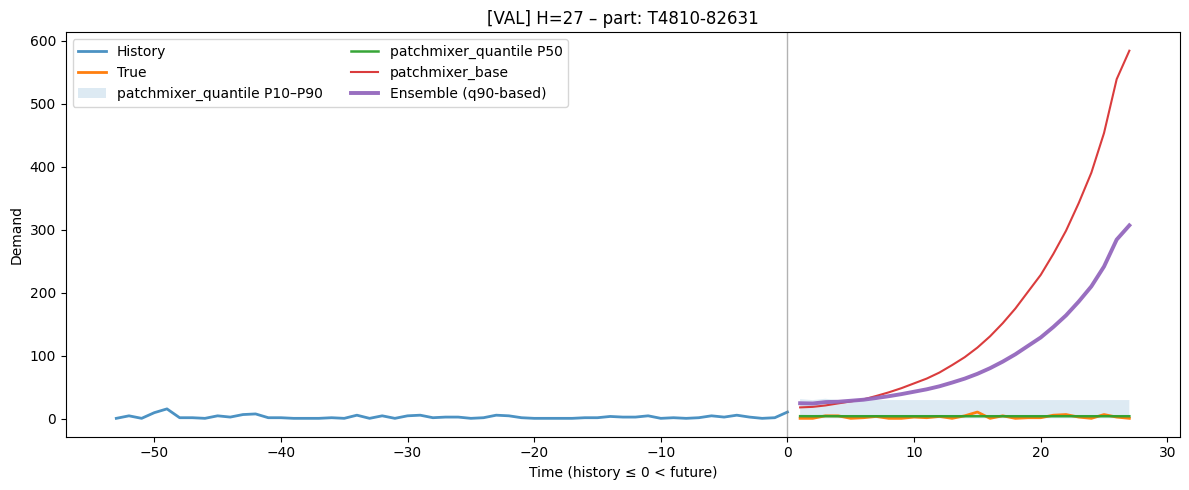

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.135284, first5=[6.70275, 6.02196, 6.28616, 6.82361, 7.0435]
[FCAST-DBG] DMS step=0: raw_n=6.70275
final
[FCAST-DBG] DMS step=1: raw_n=6.02196
final
[FCAST-DBG] DMS step=2: raw_n=6.28616
final
[FCAST-DBG] DMS step=3: raw_n=6.82361
final
[FCAST-DBG] DMS step=4: raw_n=7.0435
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
[FCAST-DBG] DONE: H=27, var=4.85627e+07, first5=[19.3535, 22.1832, 28.0284, 37.4207, 49.4375]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=1.04374 q50=4.34096 q90=30.029
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.04374 q50=4.34096 q90=30.029
[Q-IMS][PatchMixer QuantileModel] t=2 q10=1.04374 q50=4.34096 q90=30.029
[Q-IMS][PatchMixer QuantileModel] t=3 q10=1.04374 q50=4.34096 q90=30.029
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.04374 q50=4.34096 q90=30.029
[PLOT-DBG] patchmixer_base point(H=27): var(H)=4.67641e+07, mean(H)=4082.17, unique(H)=27


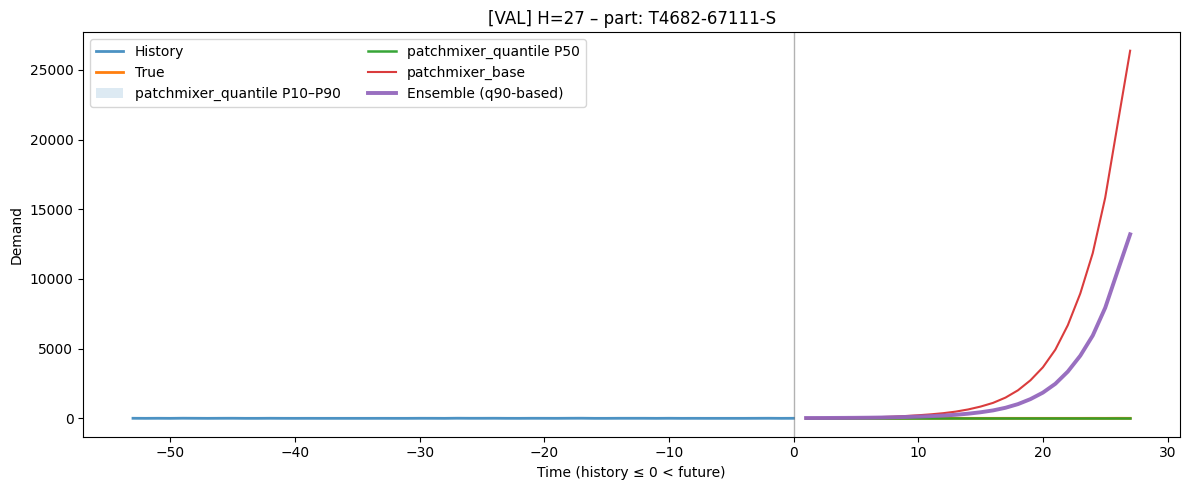

[FCAST-DBG] DMS block: Hm=27, var(Hm)=0.611445, first5=[8.89938, 7.41369, 7.1011, 6.75306, 6.28776]
[FCAST-DBG] DMS step=0: raw_n=8.89938
final
[FCAST-DBG] DMS step=1: raw_n=7.41369
final
[FCAST-DBG] DMS step=2: raw_n=7.1011
final
[FCAST-DBG] DMS step=3: raw_n=6.75306
final
[FCAST-DBG] DMS step=4: raw_n=6.28776
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
final
[FCAST-DBG] DONE: H=27, var=1.66697e+08, first5=[238.909, 292.529, 373.435, 469.228, 566.79]
[Q-IMS][PatchMixer QuantileModel] t=0 q10=0.969861 q50=4.75718 q90=38.2252
[Q-IMS][PatchMixer QuantileModel] t=1 q10=1.19418 q50=7.91198 q90=90.2592
[Q-IMS][PatchMixer QuantileModel] t=2 q10=0.898204 q50=5.08268 q90=45.8059
[Q-IMS][PatchMixer QuantileModel] t=3 q10=0.830696 q50=9.1213 q90=119.954
[Q-IMS][PatchMixer QuantileModel] t=4 q10=1.04073 q50=4.37428 q90=30.5391
[PLOT-DBG] patchmixer_base point(H=27): var(H)=1.60523e+08, mean(H)=9183.7, unique(H

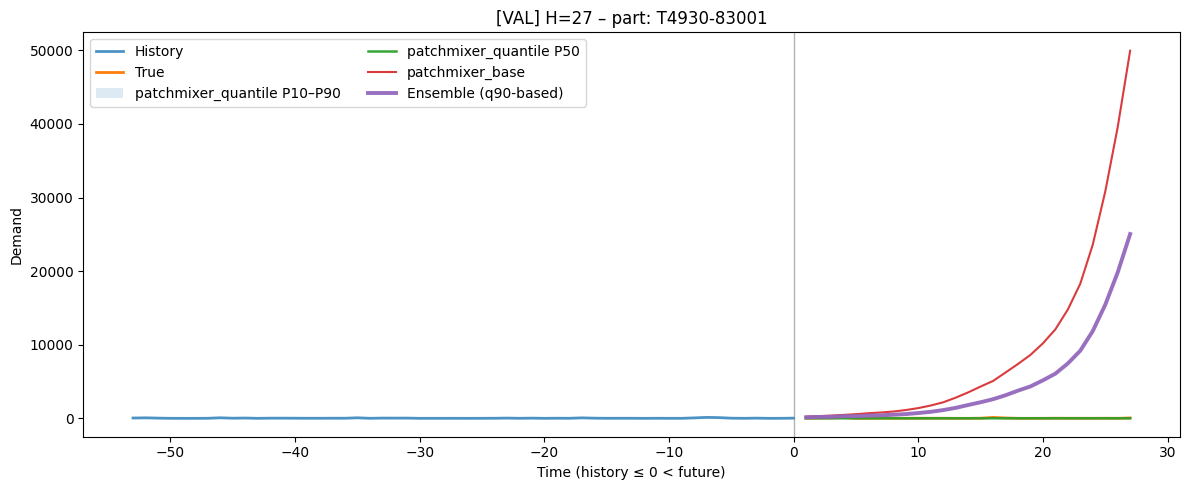

In [19]:
%load_ext autoreload
%autoreload 2

import importlib, modeling_module.utils.plot_utils as pu
import modeling_module.training.forecaster as fo
importlib.reload(pu)
importlib.reload(fo)

def my_exo_cb(start_idx: int, Hm: int, device="cuda" if torch.cuda.is_available() else "cpu"):
    # exo_dim = 2 (sin, cos)
    return fo.make_calendar_exo(start_idx, Hm, period=52, device=device)

pu.plot_27w(
    models=loaded,           # {"PatchMixer": pm_model, "Titan": ti_model, ...}
    loader=val_loader,       # (xb, yb[, part_ids])
    device="cuda" if torch.cuda.is_available() else "cpu",
    mode="val",              # ← 검증 모드
    max_plots=5,
    out_dir=None,
    show=True,
    future_exo_cb=my_exo_cb
)

In [18]:
import importlib
from modeling_module.utils import temporal_expander as te
from modeling_module.models.PatchMixer import PatchMixer as pm

te  = importlib.reload(te)   # Expander 변경 반영
pm  = importlib.reload(pm)   # PatchMixer 변경 반영
old = loaded['patchmixer_base']        # 예전 인스턴스
sd  = old.state_dict()                  # 가중치만 백업
cfg = pm_base_config  # 같은 horizon/enc_in 등
exo_dim = getattr(old, 'exo_dim', 0)

new_model = pm.BaseModel(configs=cfg, exo_dim=exo_dim)
missing, unexpected = new_model.load_state_dict(sd, strict=False)
print("missing:", missing)       # 새로 추가된 레이어들은 여기로 나옵니다(정상)
print("unexpected:", unexpected) # 구조가 바뀐 옛 키(예: fc.*)는 여기로(정상)

import torch.nn as nn
if hasattr(new_model, 'out_scale'): new_model.out_scale.data.fill_(1.0)
if hasattr(new_model, 'out_bias'):  new_model.out_bias.data.zero_()
if hasattr(new_model, 'step_gate_fc'):
    nn.init.constant_(new_model.step_gate_fc.bias, 0.5)

new_model = new_model.to(device).eval()
loaded['patchmixer_base'] = new_model
model = new_model   # 이후엔 이 객체로 사용

# model = loaded['patchmixer_base'].to(device).eval()

# with torch.no_grad():
#     z = model.backbone(x1)
#     x_bhf = model.expander(z)
#     r0 = model.head(x_bhf).squeeze(-1)
#     g_pre = model.step_gate_fc(model.gate_ln(x_bhf)) / model.gate_temp
#     g0 = torch.sigmoid(g_pre).squeeze(-1)
#
#     print("resid var(H):", r0.var(dim=1).mean().item())
#     print("gate mean/std:", g0.mean().item(), g0.std().item())
#     y = model(x1)
#     print("y var(H):", y.var(dim=1).mean().item())


# 모델 forward 직후 값 (정규화 공간)
with torch.no_grad():
    y_n = model(x1)                        # [1, H]
    # RevIN은 [B, T, C]를 기대하므로 채널 차원 추가
    y_denorm = model.revin(y_n.unsqueeze(-1), 'denorm').squeeze(-1)

print("norm-space stats:", float(y_n.min()), float(y_n.max()))
print("denorm-space stats:", float(y_denorm.min()), float(y_denorm.max()))


missing: []
unexpected: []
norm-space stats: 4.755875587463379 5.9174909591674805
denorm-space stats: 95.03167724609375 115.2625732421875


In [10]:
# plan_yyyyww 기준으로 과거 히스토리 + 27주 예측을 그림
# pu.plot_27w(
#     models=loaded,
#     loader=inference_loader,  # (xb, part_ids)
#     device="cuda",
#     mode="infer",             # ← 추론 모드
#     plan_yyyyww=202544,       # 앵커 주차(예: 2025년 44주)
#     max_plots=10,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb,
#     # 필요하면 GT를 불러오는 콜백(옵션)
#     truth_cb=None            # 또는 truth_cb(part_id, plan_dt, H=27, 'week') -> np.ndarray
# )

In [11]:
# pu.plot_120m(
#     models=loaded,
#     loader=val_loader,       # (xb, yb[, part_ids])
#     device="cuda",
#     mode="val",
#     max_plots=5,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb
# )

In [12]:
# pu.plot_120m(
#     models=loaded,
#     loader=inference_loader,  # (xb, part_ids)
#     device="cuda",
#     mode="infer",
#     plan_yyyymm=202510,       # 앵커 월(예: 2025년 10월)
#     max_plots=10,
#     out_dir=None,
#     show=True,
#     future_exo_cb=my_exo_cb,
#     # 필요하면 월 단위 GT 조회 콜백
#     truth_cb=None            # 또는 truth_cb(part_id, plan_dt, H=120, 'month') -> np.ndarray
# )